# v6 — Stacking Transformer Blocks

This builds directly on **v5**. Steps 1–10 below carry over as-is (setup, `Head`, `MultiHeadAttention`, `FeedForward`).

What's new:

1. We factor the (attention → feed-forward) pattern from v5 into a single reusable `TransformerBlock`.
2. `BigramLanguageModel` now stacks **4** of these blocks sequentially (`self.blocks`), instead of having one attention head and one feed-forward layer wired in directly. This is what gives the model *depth*.

## 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

In [ ]:
# emb_size = 32        # embedding size for each token
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [2]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

emb_size = 32        # embedding size for each token
batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [3]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [5]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [7]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [8]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[54, 60, 57,  0, 52, 54, 59, 47],
        [ 0, 52, 40, 64,  0, 58, 59, 48],
        [44, 58, 58, 54, 57,  0, 15, 51],
        [58, 40, 48, 43,  0, 19, 44, 44],
        [58, 59, 60, 43, 44, 53, 59, 58],
        [57, 40, 48, 59,  0, 58, 62, 60],
        [ 0, 40, 42, 42, 54, 52, 55, 40],
        [ 0, 40, 58,  0, 47, 44,  0, 43],
        [40, 50, 48, 53, 46,  0, 54, 60],
        [48, 58,  0, 48, 53,  0, 45, 40],
        [51, 40, 55,  0, 55, 60, 57, 57],
        [59,  0, 47, 48, 58,  0, 55, 54],
        [57, 44,  0, 47, 40, 43,  0, 59],
        [21, 40, 57, 57, 64,  0,  2, 27],
        [41, 51, 48, 53, 50, 48, 53, 46],
        [ 0, 41, 54, 64,  0, 47, 44, 58],
        [47, 54,  0, 62, 40, 58,  0, 58],
        [44,  0, 58, 52, 48, 57, 50, 44],
        [ 0, 59, 47, 44, 64,  0, 55, 40],
        [40, 57, 57, 64,  0, 51, 40, 60],
        [40, 51, 51, 64,  0, 21, 40, 46],
        [59,  0, 52, 44,  0, 52, 54, 58],
        [47, 40, 61, 44,  0, 43, 57, 40],
      

## 7. Estimating loss

In [9]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. Self-attention head (recap)

In [10]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x) # (B,T,H)
        query = self.query(x) # (B,T,H)

        # compute the attention weights
        dot_products = query @ key.transpose(-2,-1) * C**-0.5 # (B,T,H) @ (B,H,T) = (B,T,T) # scale by sqrt(d_k)
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mask out the upper triangular part
        weights = F.softmax(dot_products, dim=-1) # (B,T,T) Apply softmax to get the attention weights

        # apply the attention weights to the values
        value = self.value(x) # (B,T,H)
        out = weights @ value # (B,T,T) @ (B,T,H) = (B,T,H)
        return out

## 9. Multi-head attention (recap)

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

## 10. Feed-forward layer (recap)

In [12]:
class FeedForward(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_size, emb_size),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

## 11. Transformer block — what's new

A `TransformerBlock` is just the (attention → feed-forward) pattern from v5, packaged into its own module so we can stack several of them.

**In class:** fill in the parts marked **NEW** below.

In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, embd_size, num_heads):
        super().__init__()
        head_size = embd_size // num_heads
        # NEW: one block = one multi-head attention layer + one feed-forward layer
        self.att_head = MultiHeadAttention(num_heads, head_size)
        self.feedforward = FeedForward(embd_size)

    def forward(self, x):
        # NEW: attention first (tokens exchange information with each other)...
        x = self.att_head(x)
        # NEW: ...then feed-forward (each token processes what it gathered)
        x = self.feedforward(x)
        return x

## 12. The model — what's new

`BigramLanguageModel` no longer has a single `att_head` / `feedforward` pair. Instead it has `self.blocks`, a stack of 4 `TransformerBlock`s applied one after another.

**In class:** fill in the parts marked **NEW** below.

In [14]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        # we will get to the position embeddings later
        self.position_embedding_table = nn.Embedding(block_size, emb_size)
        # NEW: stack 4 TransformerBlocks instead of a single attention + feed-forward pair
        self.blocks = nn.Sequential(
            TransformerBlock(emb_size, num_heads=8),
            TransformerBlock(emb_size, num_heads=8),
            TransformerBlock(emb_size, num_heads=8),
            TransformerBlock(emb_size, num_heads=8)
        )
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        # NEW: pass through the stack of transformer blocks
        x = self.blocks(x) # (B,T,C)
        logits = self.linear_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the block size
            idx_cond = idx[:, -block_size:] # (B, T)

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

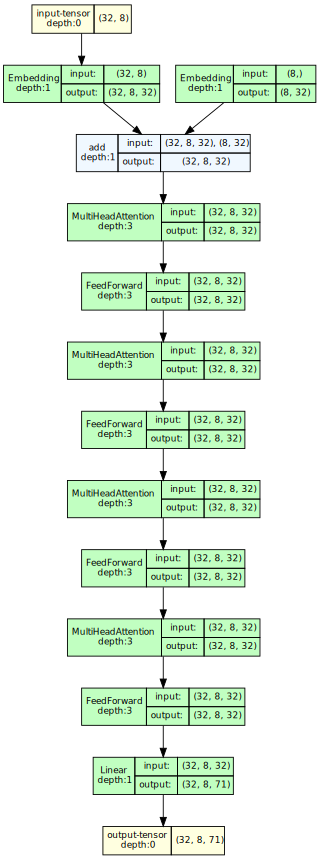

In [15]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [16]:
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 32)
  (position_embedding_table): Embedding(8, 32)
  (blocks): Sequential(
    (0): TransformerBlock(
      (att_head): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=32, out_features=4, bias=False)
            (query): Linear(in_features=32, out_features=4, bias=False)
            (value): Linear(in_features=32, out_features=4, bias=False)
          )
        )
      )
      (feedforward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=32, bias=True)
          (1): ReLU()
        )
      )
    )
    (1): TransformerBlock(
      (att_head): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=32, out_features=4, bias=False)
            (query): Linear(in_features=32, out_features=4, bias=False)
            (value): Linear(in_features=32, out_features=4, bi

## 13. Sanity check: untrained generation

In [17]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.021383 M parameters
 cz6t!□B8QmW□yCO2BmS4~E■2‘XnT~cWQZC•p6Bj3Wo7wbjI3tzGxYC‘lWDO4MXR6wJkQouvhrBaLHvHSO0Xpqf5QoOr?TdOt5VFHbnDx83dJdSLuIQc0OkHWGl1mMDBEh5iMor‘a1g•gX1lTZvCGEft3kYzNUEforGEs•l7bS□8i4G~BTdiMgcE■vSv4NPavtNnDghbd


## 14. Training the model

In [18]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.2179, val loss 4.2185
step 500: train loss 2.8699, val loss 2.8542
step 1000: train loss 2.6680, val loss 2.6446
step 1500: train loss 2.5805, val loss 2.5549
step 2000: train loss 2.5165, val loss 2.4998
step 2500: train loss 2.4557, val loss 2.4462
step 3000: train loss 2.4099, val loss 2.3968
step 3500: train loss 2.3580, val loss 2.3368
step 4000: train loss 2.3726, val loss 2.3401
step 4500: train loss 2.3282, val loss 2.2957
step 5000: train loss 2.3140, val loss 2.2910
step 5500: train loss 2.2753, val loss 2.2412
step 6000: train loss 2.2635, val loss 2.2441
step 6500: train loss 2.2610, val loss 2.2308
step 7000: train loss 2.2256, val loss 2.2331
step 7500: train loss 2.2112, val loss 2.1952
step 8000: train loss 2.2113, val loss 2.1964
step 8500: train loss 2.2032, val loss 2.1755
step 9000: train loss 2.1861, val loss 2.1605
step 9500: train loss 2.1704, val loss 2.1490
step 9999: train loss 2.1627, val loss 2.1632


*we need normalization and ? parameters to make sure gradients flow as we scale the model*

## 15. Generate text from the trained model

In [19]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 mraming wat arond it youurply awir thiklloy lumbed Rhe karry bast .Hin toungsitap the a to youn thre sons sisake doomeanckoup aond the impenrer Harry to Hal wates of Ichem Movamy a cralen and that couveltilme dairund Fly thice fidt Lont nooled wering Herrmesaltedeg Harryo ce Hreard aporis they shagked rees wand watetacatal to the Inn hour axataory a li His sizped So what Harry daily auted to unrlpled wew Lrooted aggaled .Kagh an andif of .son acres youm onte .F bow atk helle athet cringl pomber that oan sealp yas nantoughe ice stebidely giled Be hing Ix revinged afing hapec are Hel boolrid of slos furbe plaby woped hit ?don ashout .M ?In !Ghiby bet comem mecberly Harted wusgrot and anns this .He deblie slido to ?Bel as of basis ale of ..Duret is metlsely lnoind Inamy .Neae mistment her ice thes glut wame watidly a sat to said thes stay bukothed wisticw bagk